In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os
import json
import importlib
import inspect
import argparse
import pandas as pd

from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import OrderedDict

import numpy as np
import torch
from torch.utils.data import DataLoader

from import_model import import_model
from import_dataset import import_dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
train_session_dir = "train_sessions/EncoderDecoderLSTM_20250625_233028"

In [4]:
json_to_inference = os.path.join(train_session_dir,"args.json")
with open(json_to_inference, 'r') as f:
    data = json.load(f)

In [5]:
model_name = data["model_name"]

train_pred_name = f'{model_name}_train_pred_series.pt'
val_pred_name = f'{model_name}_val_pred_series.pt'

train_pred_path = os.path.join(train_session_dir, train_pred_name)
val_pred_path = os.path.join(train_session_dir, val_pred_name)

target_and_pred_names = [train_pred_name, val_pred_name]
model_pt_name = [x for x in os.listdir(train_session_dir) if x.endswith(".pt") and x not in target_and_pred_names][0]
model_pt_path = os.path.join(train_session_dir, model_pt_name)

In [6]:
args = argparse.Namespace(**data)

base_dataset_kwargs = { "coin_symbol": args.coin_symbol, "input_window": args.input_window, "output_window": args.output_window,
    "augmentation_noise_std": args.augmentation_noise_std, "augment_constant_c": args.augment_constant_c, "augment_scale_s": args.augment_scale_s,
    "distribution_scale": args.distribution_scale, "distribution_clip": args.distribution_clip, "transform_name":args.transform_name,
    "output_distribution": args.output_distribution, "n_quantiles": args.n_quantiles, "train_session_dir": train_session_dir}

inference_val_dataset_kwargs = {**base_dataset_kwargs, "csv_path": args.val_csv_path, "augmentation_p": 0, "training_dataset":0}
inference_val_dataset = import_dataset(args.dataset_name, **inference_val_dataset_kwargs)
inference_val_loader = DataLoader(inference_val_dataset, batch_size=args.batch_size, shuffle=False)

inference_train_dataset_kwargs = {**base_dataset_kwargs, "csv_path": args.train_csv_path, "augmentation_p": 0, "training_dataset":1}
inference_train_dataset = import_dataset(args.dataset_name, **inference_train_dataset_kwargs)
inference_train_loader = DataLoader(inference_train_dataset, batch_size=args.batch_size, shuffle=False)

model_kwargs = {"input_features": args.input_features, "output_features": args.output_features,
"input_window": args.input_window, "output_window": args.output_window,
"dropout": args.dropout, "num_layers": args.num_layers,
"hidden_dim": args.hidden_dim, "num_heads": args.num_heads,
"teacher_forcing_ratio": args.teacher_forcing_ratio,
"target_coin_index": args.target_coin_index,
"num_coins": args.num_coins, "device": device}

In [7]:
model = import_model(args.model_name, **model_kwargs)
model.load_state_dict(torch.load(model_pt_path, weights_only=True))

<All keys matched successfully>

In [8]:
trust = 0

In [10]:
# DATA THE MODEL HAS SEEN IN THE TRAINING LOOP
# WILL BE USED TO SHOW HOW GOOD ARE MODELS PREDICTIONS, ALSO WILL BE PLOTTED AS THE REAL PRICE TO CHECK THE DIFFERENCE PREPROCESSING CAUSE
train_learned_dataframe_crop = inference_train_dataset.df.iloc[data["input_window"]+1+trust:-(data["output_window"]-2-trust)]
val_learned_dataframe_crop = inference_val_dataset.df.iloc[data["input_window"]+1+trust:-(data["output_window"]-2-trust)]

In [11]:
# MODEL'S PREDICTIONS
# WILL BE USED TO CHECK HOW GOOD MODELS PREDICTIONS ARE, ALSO WILL BE RE-SCALE TO REAL PRICE DATA AND CHECK THE DIFFERENCE THE TRANSFORMS CAUSED
train_pred_series = torch.load(train_pred_path)
print("train_pred_series:", train_pred_series.shape)
val_pred_series = torch.load(val_pred_path)
print("val_pred_series:", val_pred_series.shape)

train_pred_series: torch.Size([4, 9171, 8])
val_pred_series: torch.Size([4, 988, 8])


In [39]:
# REAL VALIDATION DATA
# WILL BE USED TO PLOT REAL PRICE GRAPH
df = pd.read_csv(data["val_csv_path"], index_col="open_time")
val_df = df[-len(inference_val_dataset.df):]
val_df_preds = val_df.iloc[data["input_window"]:-data["output_window"]+1]

df = pd.read_csv(data["train_csv_path"], index_col="open_time")
train_df = df[-len(inference_train_dataset.df):]
train_df_preds = train_df.iloc[data["input_window"]:-data["output_window"]+1]

initial_prices = torch.tensor(df.iloc[data["input_window"]+1+trust][:4].values).unsqueeze(0)
print(initial_prices)

val_df_preds

tensor([[8367.0000, 8555.0000, 8361.1300, 8610.0000]], dtype=torch.float64)


,BTC_open,BTC_close,BTC_low,BTC_high,ETH_open,ETH_close,ETH_low,ETH_high,BNB_open,BNB_close,BNB_low,BNB_high,XRP_open,XRP_close,XRP_low,XRP_high
open_time,,,,,,,,,,,,,,,,
2024-08-29 06:00:00,59436.17,60067.06,59370.00,60477.00,2540.77,2555.21,2536.45,2574.22,543.40,543.70,539.90,545.30,0.5736,0.5745,0.5712,0.5770
2024-08-29 12:00:00,60067.06,60533.00,59990.00,61166.99,2555.20,2576.53,2552.14,2595.40,543.70,540.40,536.90,545.50,0.5745,0.5728,0.5704,0.5770
2024-08-29 18:00:00,60533.00,59359.01,58713.09,60548.99,2576.52,2527.61,2505.88,2577.84,540.40,536.40,530.90,540.50,0.5728,0.5619,0.5573,0.5730
2024-08-30 00:00:00,59359.00,58784.00,58685.00,59487.64,2527.60,2511.19,2503.80,2535.40,536.40,529.20,529.00,537.60,0.5618,0.5591,0.5586,0.5652
2024-08-30 06:00:00,58783.99,59396.00,58705.01,59674.42,2511.20,2512.44,2506.33,2533.52,529.20,538.40,528.30,540.80,0.5591,0.5638,0.5574,0.5661
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-02 00:00:00,96489.90,96707.54,96466.21,97309.78,1838.10,1832.10,1828.96,1851.79,599.64,598.81,598.34,603.61,2.2122,2.2123,2.2076,2.2336
2025-05-02 06:00:00,96707.54,96928.97,96350.00,97100.00,1832.10,1833.39,1813.00,1837.40,598.81,597.85,595.12,600.65,2.2122,2.2151,2.1920,2.2200
2025-05-02 12:00:00,96928.97,97402.55,96650.94,97895.68,1833.39,1852.35,1823.34,1871.00,597.85,600.21,596.63,601.89,2.2151,2.2147,2.2060,2.2411


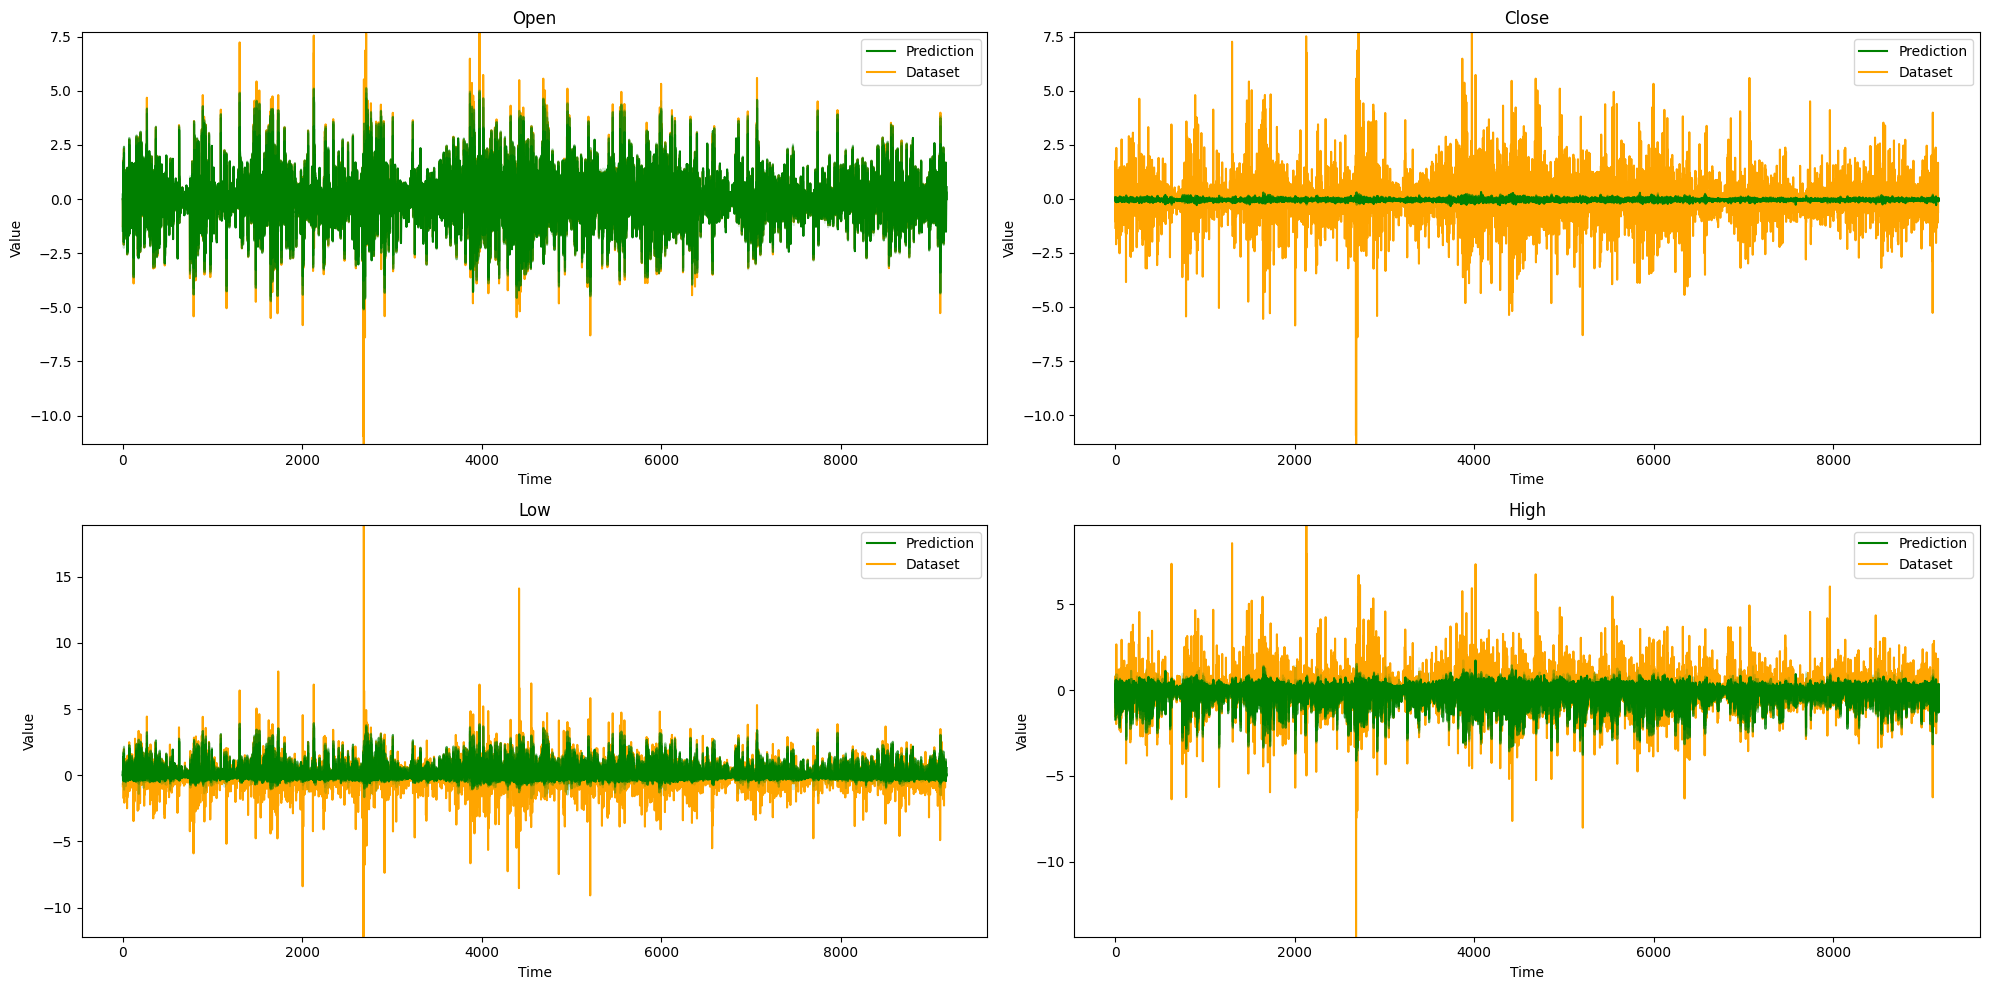

In [28]:
pred_series_with_different_trusts = []
for trust in range(8):
    pred_series_with_different_trusts.append(torch.cat((torch.zeros(train_pred_series.shape[0], trust), train_pred_series[:,:,trust], train_pred_series[:,-1,trust:]), dim=1))

feature_names = ["Open", "Close", "Low", "High"]
plt.figure(figsize=(20, 10))

for i in range(4):
    plt.subplot(2, 2, i + 1)
    
    ground_truth = train_learned_dataframe_crop[inference_train_dataset.coin_cols].values.T[i]
    plt.plot(ground_truth, label="Dataset", color="orange")
    for trust, pred_series_to_plot in enumerate(pred_series_with_different_trusts):
        plt.plot(pred_series_to_plot[i], label="Prediction", color="green", alpha=1/(trust+1))

    plt.title(f'{feature_names[i]}')
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.ylim(ground_truth.min(), ground_truth.max())
    plt.legend()

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = OrderedDict(zip(reversed(labels), reversed(handles)))
    plt.legend(by_label.values(), by_label.keys())    

plt.tight_layout()
plt.show()

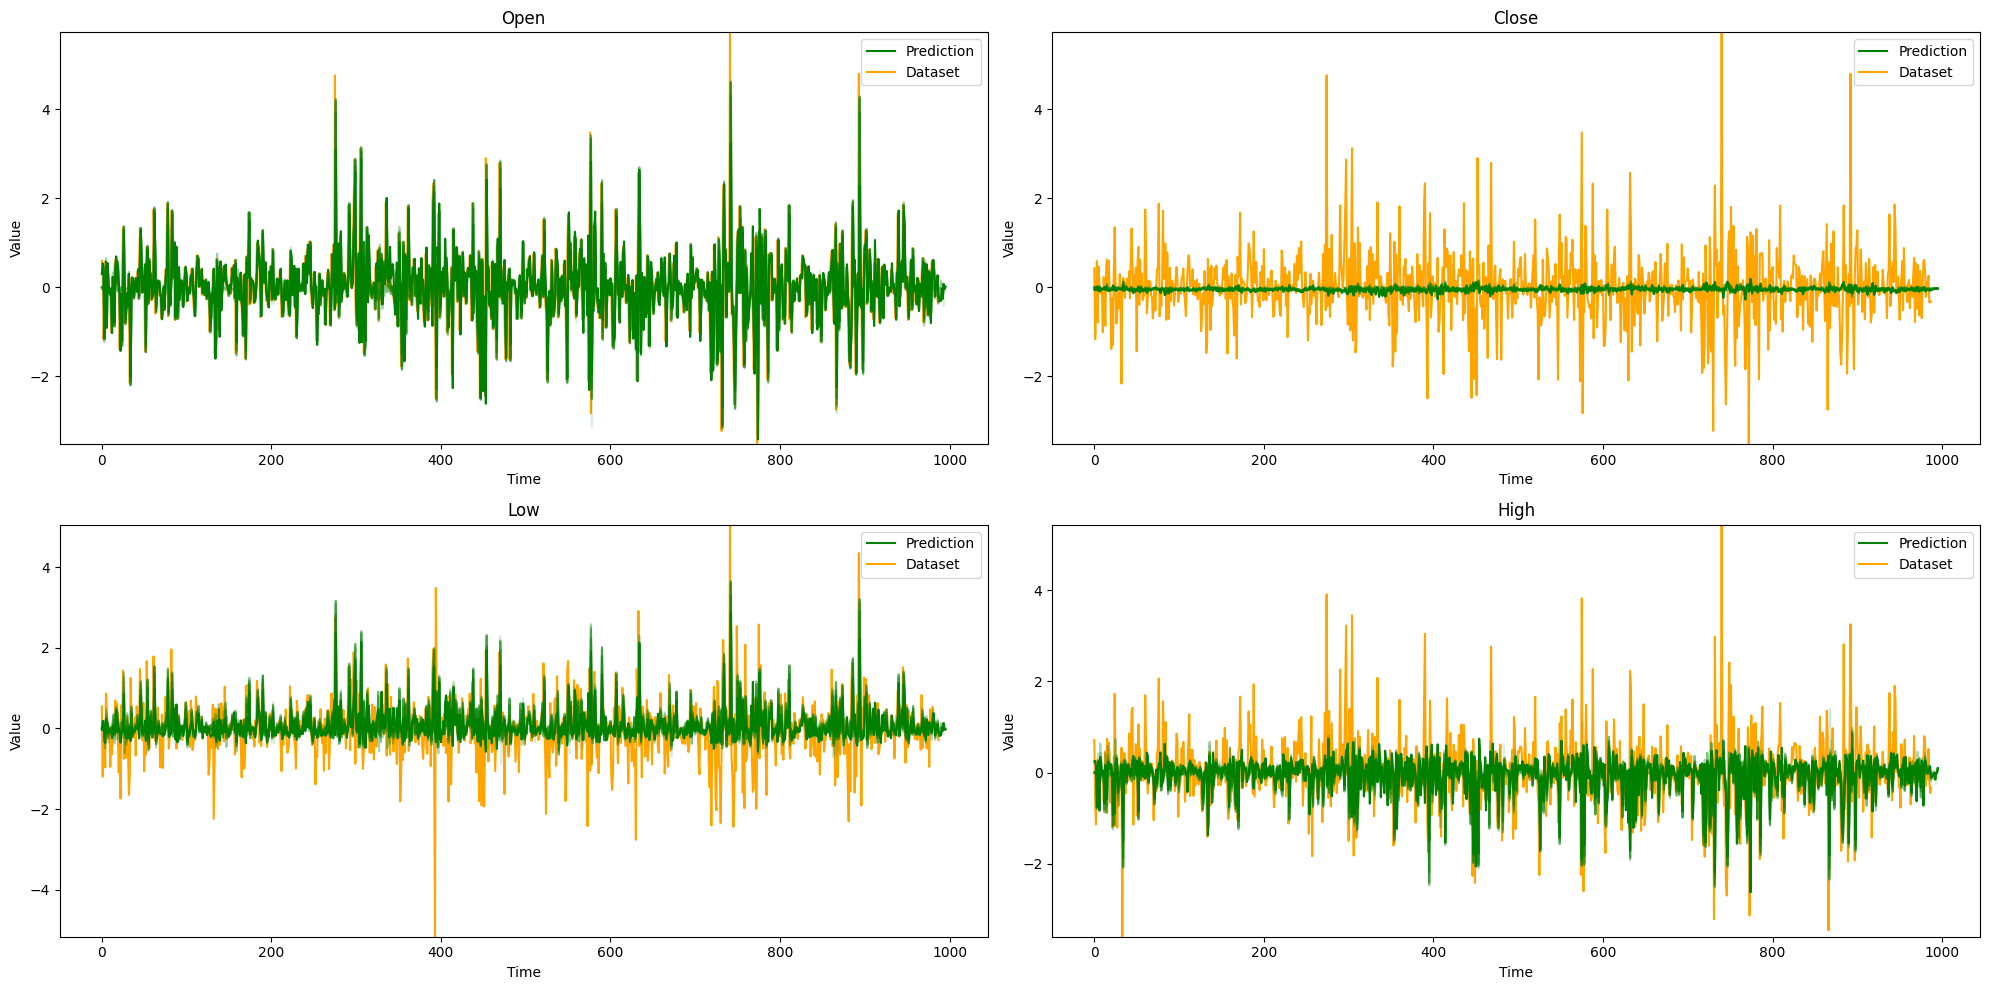

In [27]:
pred_series_with_different_trusts = []
for trust in range(8):
    pred_series_with_different_trusts.append(torch.cat((torch.zeros(val_pred_series.shape[0], trust), val_pred_series[:,:,trust], val_pred_series[:,-1,trust:]), dim=1))

feature_names = ["Open", "Close", "Low", "High"]
plt.figure(figsize=(20, 10))

for i in range(4):
    plt.subplot(2, 2, i + 1)
    
    ground_truth = val_learned_dataframe_crop[inference_val_dataset.coin_cols].values.T[i]
    plt.plot(ground_truth, label="Dataset", color="orange")
    for trust, pred_series_to_plot in enumerate(pred_series_with_different_trusts):
        plt.plot(pred_series_to_plot[i], label="Prediction", color="green", alpha=1/(trust+1))

    plt.title(f'{feature_names[i]}')
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.ylim(ground_truth.min(), ground_truth.max())
    plt.legend()

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = OrderedDict(zip(reversed(labels), reversed(handles)))
    plt.legend(by_label.values(), by_label.keys())    

plt.tight_layout()
plt.show()

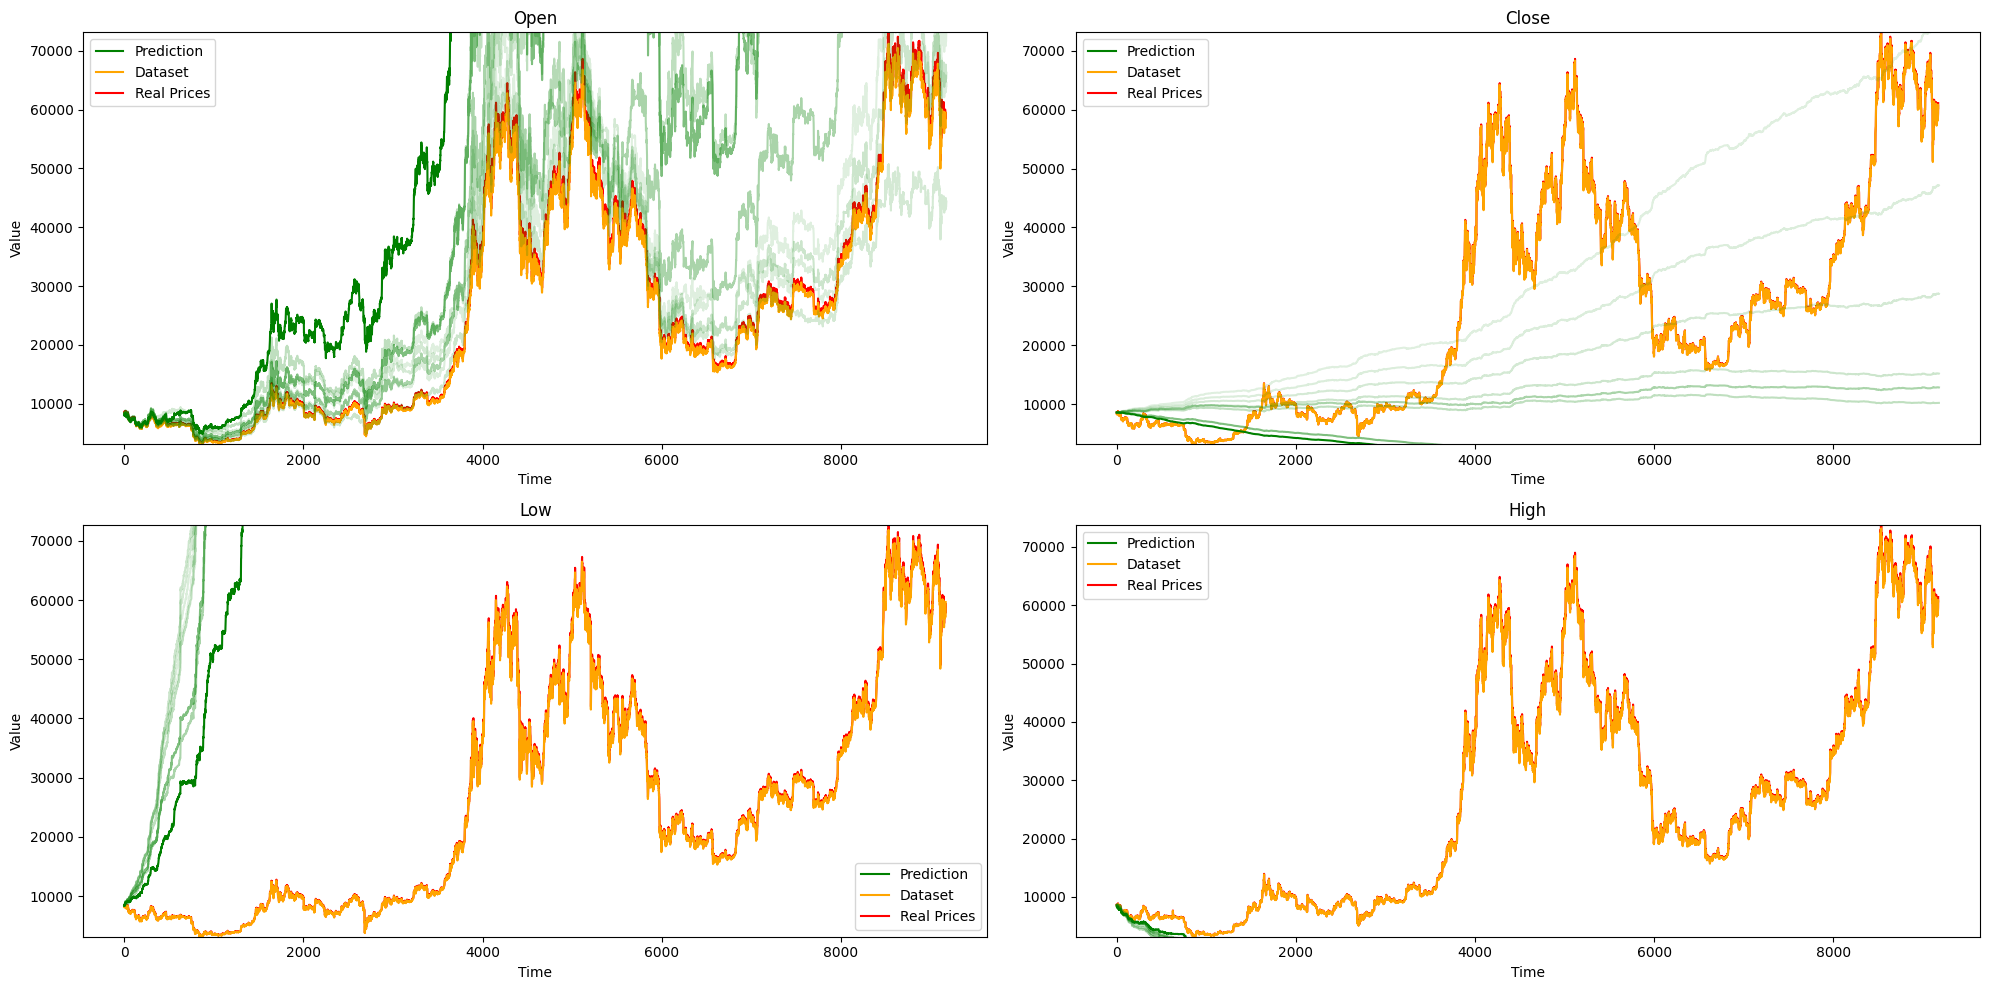

In [40]:
rescaled_target_series_to_plot = inference_val_dataset.rescale_to_real_price(train_learned_dataframe_crop[inference_val_dataset.coin_cols].values, initial_prices).T

pred_series_with_different_trusts = []
for trust in range(8):
    pred_series_with_different_trusts.append(torch.cat((torch.zeros(train_pred_series.shape[0], trust), train_pred_series[:,:,trust], train_pred_series[:,-1,trust:]), dim=1))

feature_names = ["Open", "Close", "Low", "High"]
plt.figure(figsize=(20, 10))

for i in range(4):
    plt.subplot(2, 2, i + 1)
    
    real_prices = train_df_preds[inference_val_dataset.coin_cols].values.T[i]
    plt.plot(real_prices, label="Real Prices", color="red")

    ground_truth = rescaled_target_series_to_plot[i]
    plt.plot(ground_truth, label="Dataset", color="orange")
    for trust, pred_series_to_plot in enumerate(pred_series_with_different_trusts):
        rescaled_pred_series_to_plot = inference_val_dataset.rescale_to_real_price(pred_series_to_plot.T, initial_prices).T
        plt.plot(rescaled_pred_series_to_plot[i], label="Prediction", color="green", alpha=1/(trust+1))

    plt.title(f'{feature_names[i]}')
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.ylim(min(ground_truth.min(), real_prices.min()), max(ground_truth.max(), real_prices.max()))
    plt.legend()

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = OrderedDict(zip(reversed(labels), reversed(handles)))
    plt.legend(by_label.values(), by_label.keys())    

plt.tight_layout()
plt.show()

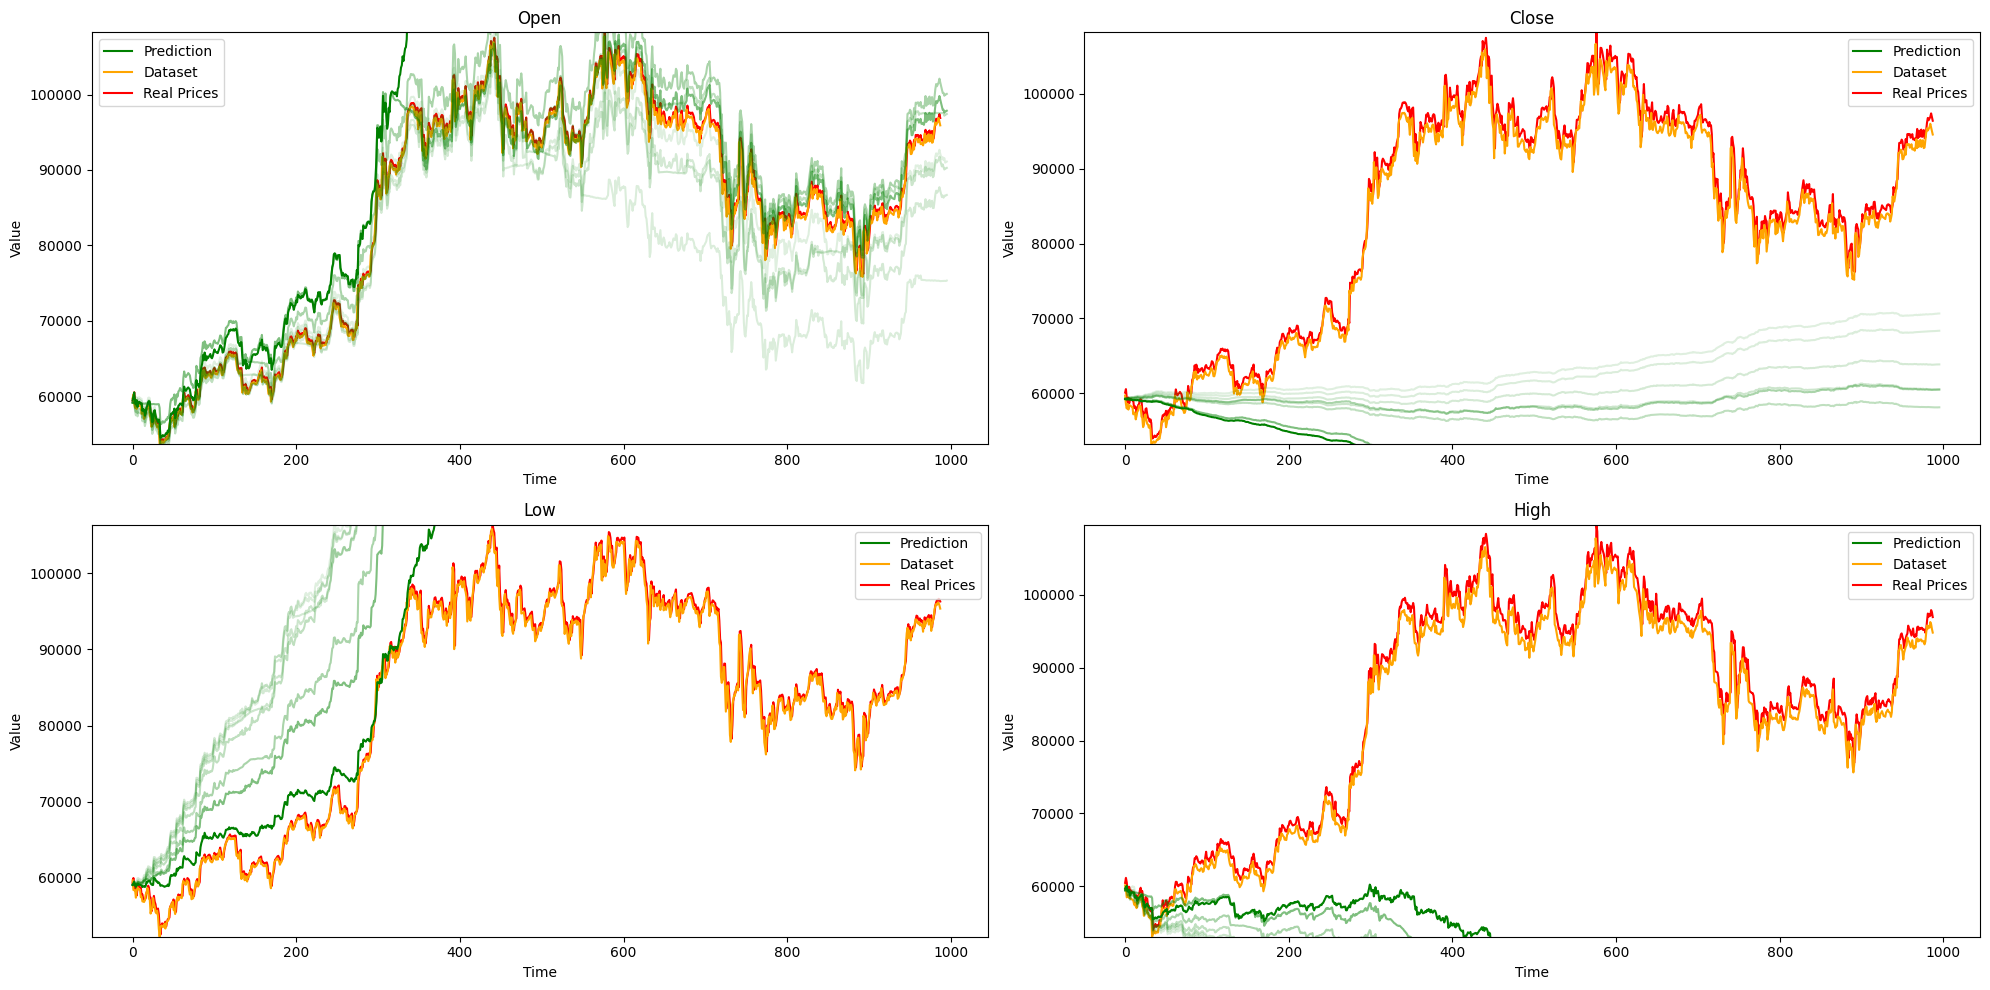

In [38]:
rescaled_target_series_to_plot = inference_val_dataset.rescale_to_real_price(val_learned_dataframe_crop[inference_val_dataset.coin_cols].values, initial_prices).T

pred_series_with_different_trusts = []
for trust in range(8):
    pred_series_with_different_trusts.append(torch.cat((torch.zeros(val_pred_series.shape[0], trust), val_pred_series[:,:,trust], val_pred_series[:,-1,trust:]), dim=1))

feature_names = ["Open", "Close", "Low", "High"]
plt.figure(figsize=(20, 10))

for i in range(4):
    plt.subplot(2, 2, i + 1)
    
    real_prices = val_df_preds[inference_val_dataset.coin_cols].values.T[i]
    plt.plot(real_prices, label="Real Prices", color="red")

    ground_truth = rescaled_target_series_to_plot[i]
    plt.plot(ground_truth, label="Dataset", color="orange")
    for trust, pred_series_to_plot in enumerate(pred_series_with_different_trusts):
        rescaled_pred_series_to_plot = inference_val_dataset.rescale_to_real_price(pred_series_to_plot.T, initial_prices).T
        plt.plot(rescaled_pred_series_to_plot[i], label="Prediction", color="green", alpha=1/(trust+1))

    plt.title(f'{feature_names[i]}')
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.ylim(min(ground_truth.min(), real_prices.min()), max(ground_truth.max(), real_prices.max()))
    plt.legend()

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = OrderedDict(zip(reversed(labels), reversed(handles)))
    plt.legend(by_label.values(), by_label.keys())    

plt.tight_layout()
plt.show()